<a href="https://colab.research.google.com/github/ChSivamowny15/Cartoons-identification-using-VGG16/blob/main/CAD_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing necessary libraries
import numpy as np              # For numerical operations
import pandas as pd             # For data manipulation and analysis
import matplotlib.pyplot as plt # For plotting graphs
import seaborn as sns           # For visualization
from sklearn.model_selection import train_test_split   # To split the data
from sklearn.preprocessing import StandardScaler       # To standardize the data
from sklearn.linear_model import LogisticRegression    # Logistic Regression Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Model evaluation

# Optional for Jupyter (but required in Colab):
%matplotlib inline


In [ ]:
# Load the dataset (either upload your own dataset or use a public dataset)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Reading the data into a pandas DataFrame
df = pd.read_csv(url, names=columns)
df.head()  # View the first few rows


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
# Replace '?' with NaN
df = df.replace('?', np.nan)

# Convert 'ca' and 'thal' columns to numeric, since they contain missing values as strings
df['ca'] = pd.to_numeric(df['ca'], errors='coerce')
df['thal'] = pd.to_numeric(df['thal'], errors='coerce')

# Fill missing values with the median (simple imputation strategy)
df.fillna(df.median(), inplace=True)

# Checking for any more missing values
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


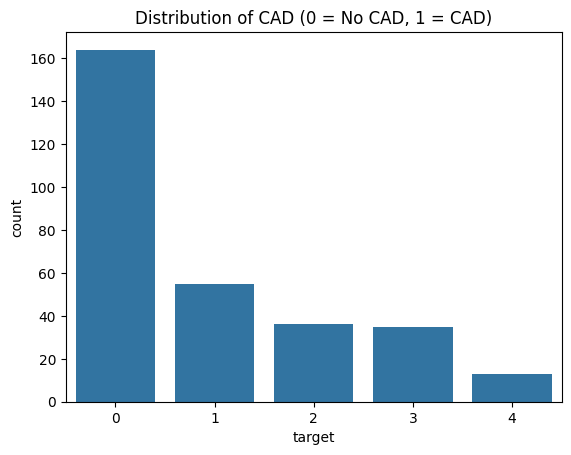

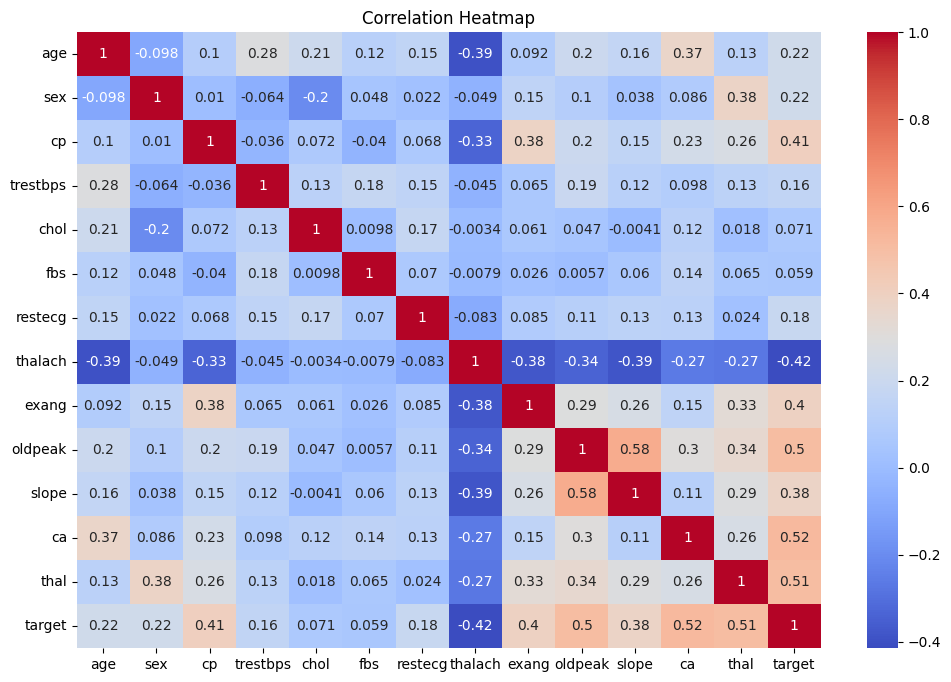

In [ ]:
# Plot the distribution of the target variable (CAD presence)
sns.countplot(x='target', data=df)
plt.title('Distribution of CAD (0 = No CAD, 1 = CAD)')

# Visualize correlation between features
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [ ]:
# Splitting the data into features (X) and target (y)
X = df.drop('target', axis=1)  # Features (all columns except 'target')
y = df['target']               # Target (the 'target' column)

# Split into train and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# Initialize the Logistic Regression model
model = LogisticRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)


Accuracy: 54.10%


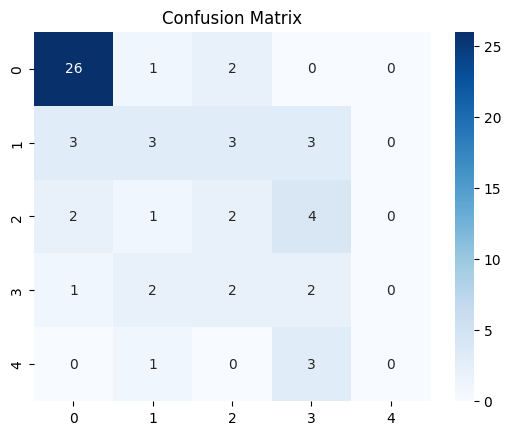

              precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.38      0.25      0.30        12
           2       0.22      0.22      0.22         9
           3       0.17      0.29      0.21         7
           4       0.00      0.00      0.00         4

    accuracy                           0.54        61
   macro avg       0.32      0.33      0.32        61
weighted avg       0.51      0.54      0.52        61



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Classification report (precision, recall, F1-score)
print(classification_report(y_test, y_pred))


In [ ]:
from sklearn.naive_bayes import GaussianNB

# Initialize Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, y_train)

# Predict using Naive Bayes
y_pred_nb = nb_model.predict(X_test)

# Evaluate the model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f'Naive Bayes Accuracy: {accuracy_nb * 100:.2f}%')
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 31.15%
[[15  0  1  0 13]
 [ 0  0  1  2  9]
 [ 0  1  1  1  6]
 [ 0  0  1  0  6]
 [ 0  0  0  1  3]]
              precision    recall  f1-score   support

           0       1.00      0.52      0.68        29
           1       0.00      0.00      0.00        12
           2       0.25      0.11      0.15         9
           3       0.00      0.00      0.00         7
           4       0.08      0.75      0.15         4

    accuracy                           0.31        61
   macro avg       0.27      0.28      0.20        61
weighted avg       0.52      0.31      0.36        61



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predict using Decision Tree
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree Accuracy: {accuracy_dt * 100:.2f}%')
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 45.90%
[[23  1  4  1  0]
 [ 4  2  6  0  0]
 [ 1  1  2  4  1]
 [ 1  4  1  0  1]
 [ 1  0  0  2  1]]
              precision    recall  f1-score   support

           0       0.77      0.79      0.78        29
           1       0.25      0.17      0.20        12
           2       0.15      0.22      0.18         9
           3       0.00      0.00      0.00         7
           4       0.33      0.25      0.29         4

    accuracy                           0.46        61
   macro avg       0.30      0.29      0.29        61
weighted avg       0.46      0.46      0.46        61



In [ ]:
from sklearn.svm import SVC

# Initialize SVM model
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Predict using SVM
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f'SVM Accuracy: {accuracy_svm * 100:.2f}%')
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 54.10%
[[26  1  2  0  0]
 [ 3  3  2  4  0]
 [ 2  1  2  4  0]
 [ 1  3  1  2  0]
 [ 0  1  0  3  0]]
              precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.33      0.25      0.29        12
           2       0.29      0.22      0.25         9
           3       0.15      0.29      0.20         7
           4       0.00      0.00      0.00         4

    accuracy                           0.54        61
   macro avg       0.32      0.33      0.32        61
weighted avg       0.51      0.54      0.52        61



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.neural_network import MLPClassifier

# Initialize Neural Network model
nn_model = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42)

# Train the model
nn_model.fit(X_train, y_train)

# Predict using Neural Network
y_pred_nn = nn_model.predict(X_test)

# Evaluate the model
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f'Neural Network Accuracy: {accuracy_nn * 100:.2f}%')
print(confusion_matrix(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))


Neural Network Accuracy: 49.18%
[[25  2  0  2  0]
 [ 3  2  3  4  0]
 [ 2  2  1  3  1]
 [ 1  1  3  2  0]
 [ 0  2  0  2  0]]
              precision    recall  f1-score   support

           0       0.81      0.86      0.83        29
           1       0.22      0.17      0.19        12
           2       0.14      0.11      0.12         9
           3       0.15      0.29      0.20         7
           4       0.00      0.00      0.00         4

    accuracy                           0.49        61
   macro avg       0.27      0.29      0.27        61
weighted avg       0.47      0.49      0.48        61



/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Printing all the accuracies
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")
print(f"Naive Bayes Accuracy: {accuracy_nb * 100:.2f}%")
print(f"Decision Tree Accuracy: {accuracy_dt * 100:.2f}%")
print(f"SVM Accuracy: {accuracy_svm * 100:.2f}%")
print(f"Neural Network Accuracy: {accuracy_nn * 100:.2f}%")


Logistic Regression Accuracy: 54.10%
Naive Bayes Accuracy: 31.15%
Decision Tree Accuracy: 45.90%
SVM Accuracy: 54.10%
Neural Network Accuracy: 49.18%


<ipython-input-13-60a8976a321a>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


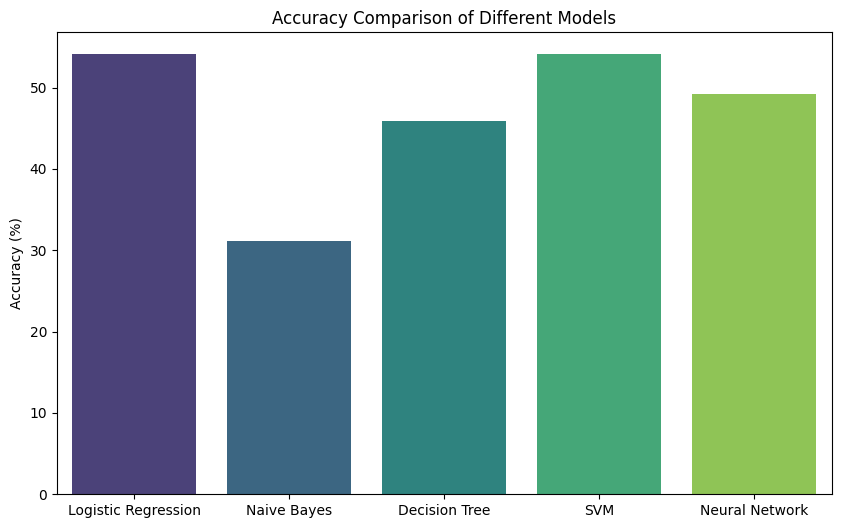

In [ ]:
import matplotlib.pyplot as plt

# Model names and their accuracies
models = ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'SVM', 'Neural Network']
accuracies = [accuracy * 100, accuracy_nb * 100, accuracy_dt * 100, accuracy_svm * 100, accuracy_nn * 100]

# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Accuracy Comparison of Different Models')
plt.ylabel('Accuracy (%)')
plt.show()
